In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/marketing_campaign.csv',sep=None, engine="python")
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


#Data Preprocessing

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
Income=df["Income"].median()

In [ ]:
df["Income"]=df["Income"].fillna(Income)

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.dtypes.value_counts()

,count
int64,25
object,3
float64,1


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


#Feature Engineering

In [ ]:
df['Age'] = 2026 - df['Year_Birth']

In [ ]:
df['TotalSpending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [ ]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

In [ ]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

In [ ]:
df = df[df['Income'] > 0]

In [ ]:
df["Income"] = np.log1p(df["Income"])
df["TotalSpending"] = np.log1p(df["TotalSpending"])

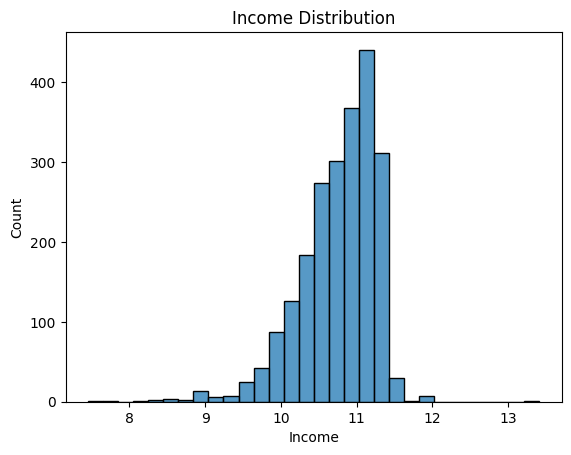

In [ ]:
sns.histplot(df['Income'], bins=30)
plt.title("Income Distribution")
plt.show()

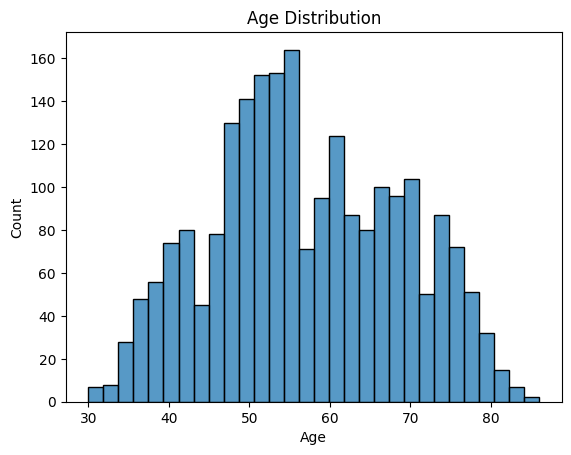

In [ ]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

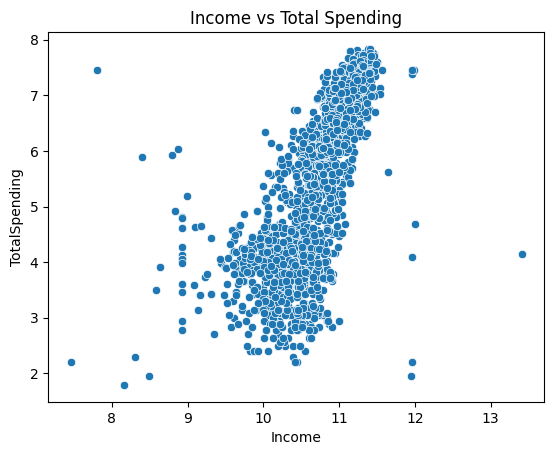

In [ ]:
sns.scatterplot(x='Income', y='TotalSpending', data=df)
plt.title("Income vs Total Spending")
plt.show()

#Encodeing

In [ ]:
education_mapping = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3}
df["Education"] = df["Education"].map(education_mapping)

#OneHotEncoder

In [ ]:
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True, dtype=int)

#Supervised Learning - Regression

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Year"] = df["Dt_Customer"].dt.year
df = df.drop("Dt_Customer", axis=1)

In [ ]:
y = df["TotalSpending"]

X = df.drop([
    "TotalSpending",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

Linear Regression

In [ ]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MSE: 0.2159881212959001
RMSE: 0.46474522191831097
R2 Score: 0.9002889246911867


Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results
MSE: 0.21597772530725529
RMSE: 0.46473403717315054
R2 Score: 0.900293724007003


Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MSE: 0.12046451836806067
RMSE: 0.3470799884292678
R2 Score: 0.9443874663524581


Model MSE RMSE R² Linear Regression 0.215 0.464 0.900 Ridge Regression 0.215 0.464 0.900
Decision Tree 0.1205 0.347 0.944

From the results, the Decision Tree model performed the best compared to Linear and Ridge Regression, achieving the highest R² score and the lowest error values, while both Linear and Ridge showed very similar performance.

#Supervised Learning - Classification

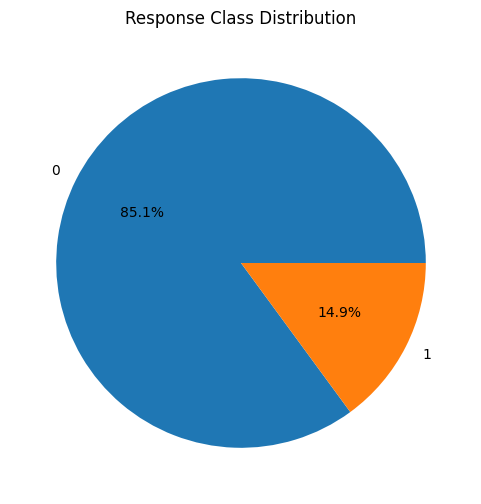

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    df["Response"].value_counts(),
    labels=df["Response"].value_counts().index,
    autopct="%1.1f%%"
)

plt.title("Response Class Distribution")
plt.show()

In [ ]:
y = df["Response"]

X = df.drop("Response", axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logistic_model = LogisticRegression(class_weight='balanced', random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logistic))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.8102678571428571

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88       381
           1       0.42      0.76      0.55        67

    accuracy                           0.81       448
   macro avg       0.69      0.79      0.71       448
weighted avg       0.87      0.81      0.83       448


Confusion Matrix:
 [[312  69]
 [ 16  51]]


K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.859375

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       381
           1       0.56      0.27      0.36        67

    accuracy                           0.86       448
   macro avg       0.72      0.62      0.64       448
weighted avg       0.83      0.86      0.84       448


Confusion Matrix:
 [[367  14]
 [ 49  18]]


Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8772321428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.71      0.30      0.42        67

    accuracy                           0.88       448
   macro avg       0.80      0.64      0.68       448
weighted avg       0.86      0.88      0.86       448


Confusion Matrix:
 [[373   8]
 [ 47  20]]


#Unsupervised Learning - Clustering

In [ ]:
cluster_features = df[['TotalSpending', 'Income', 'Age', 'TotalChildren']]

In [ ]:
cluster_features.head()

,TotalSpending,Income,Age,TotalChildren
0,7.388946,10.970592,69,0
1,3.332205,10.743869,72,2
2,6.655440,11.179046,61,0
3,3.988984,10.190432,42,1
4,6.047372,10.973254,45,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

Elbow Method

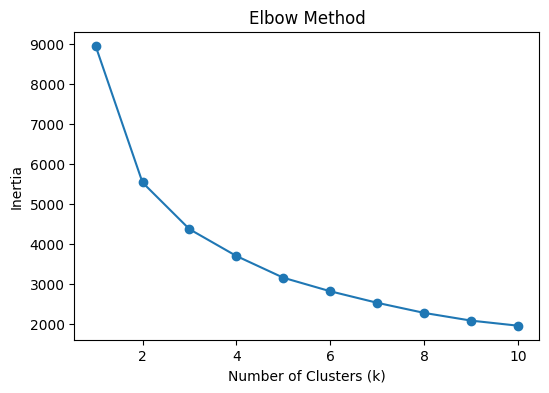

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(cluster_scaled)

In [ ]:
df["Cluster"] = clusters

In [ ]:
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,TotalChildren,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Year,Cluster
0,5524,1957,1.0,10.970592,0,0,58,635,88,546,...,0,0,0,0,1,0,0,0,2012,1
1,2174,1954,1.0,10.743869,1,1,38,11,1,6,...,2,0,0,0,1,0,0,0,2014,0
2,4141,1965,1.0,11.179046,0,0,26,426,49,127,...,0,0,0,0,0,1,0,0,2013,1
3,6182,1984,1.0,10.190432,1,0,26,11,4,20,...,1,0,0,0,0,1,0,0,2014,2
4,5324,1981,3.0,10.973254,1,0,94,173,43,118,...,1,0,0,1,0,0,0,0,2014,1


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(cluster_scaled)

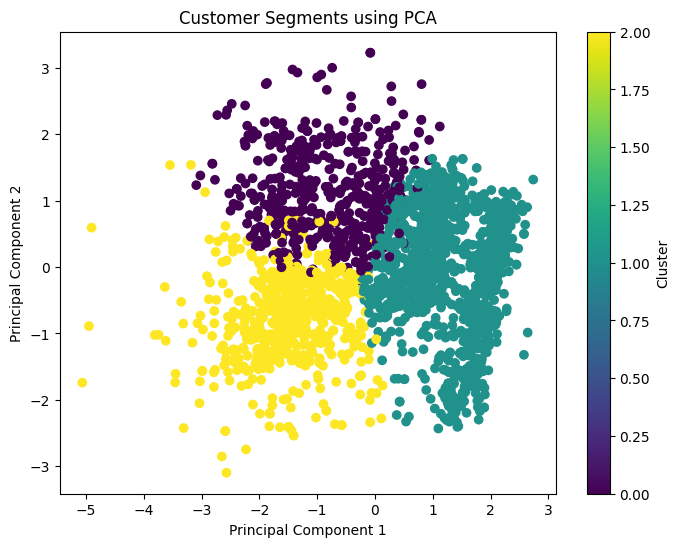

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
cluster_profile = df.groupby("Cluster")[["Income", "TotalSpending", "Age", "TotalChildren"]].mean()

cluster_profile

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,10.701175,4.844689,62.227444,1.934211
1,11.101330,6.825963,59.226570,0.517743
2,10.172559,4.118555,48.735974,0.872937


_Cluster 0: Customers in this cluster have medium income and spending. They are older and usually have more children.

_Cluster 1: Customers in this cluster have higher income and higher spending. They also have fewer children.

_Cluster 2: Customers in this cluster have lower income and lower spending. They are younger compared to the other clusters and have a moderate number of children.